## Markov Chain


## 2-State Discrete Markov Chain

Transition matrix: 
 [[0.54234059 0.45765941]
 [0.         1.        ]]
Time       No AD        AD
Time 1: [0.54234059 0.45765941]
Time 2: [0.29413331 0.70586669]
Time 3: [0.15952043 0.84047957]
Time 4: [0.08651441 0.91348559]
Time 5: [0.04692027 0.95307973]
Time 6: [0.02544677 0.97455323]
Time 7: [0.01380082 0.98619918]
Time 8: [0.00748474 0.99251526]
Time 9: [0.00405928 0.99594072]
Time 10: [0.00220151 0.99779849]
Time 11: [0.00119397 0.99880603]
Time 12: [6.47538045e-04 9.99352462e-01]
Time 13: [3.51186164e-04 9.99648814e-01]
Time 14: [1.90462510e-04 9.99809537e-01]
Time 15: [1.03295550e-04 9.99896704e-01]
Time 16: [5.60213692e-05 9.99943979e-01]
Time 17: [3.03826623e-05 9.99969617e-01]
Time 18: [1.64777509e-05 9.99983522e-01]
Time 19: [8.93655313e-06 9.99991063e-01]
Time 20: [4.84665548e-06 9.99995153e-01]


/var/folders/fl/8y0jm7_n4zbg3z6snpxmp3pw0000gn/T/ipykernel_4309/3259275908.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


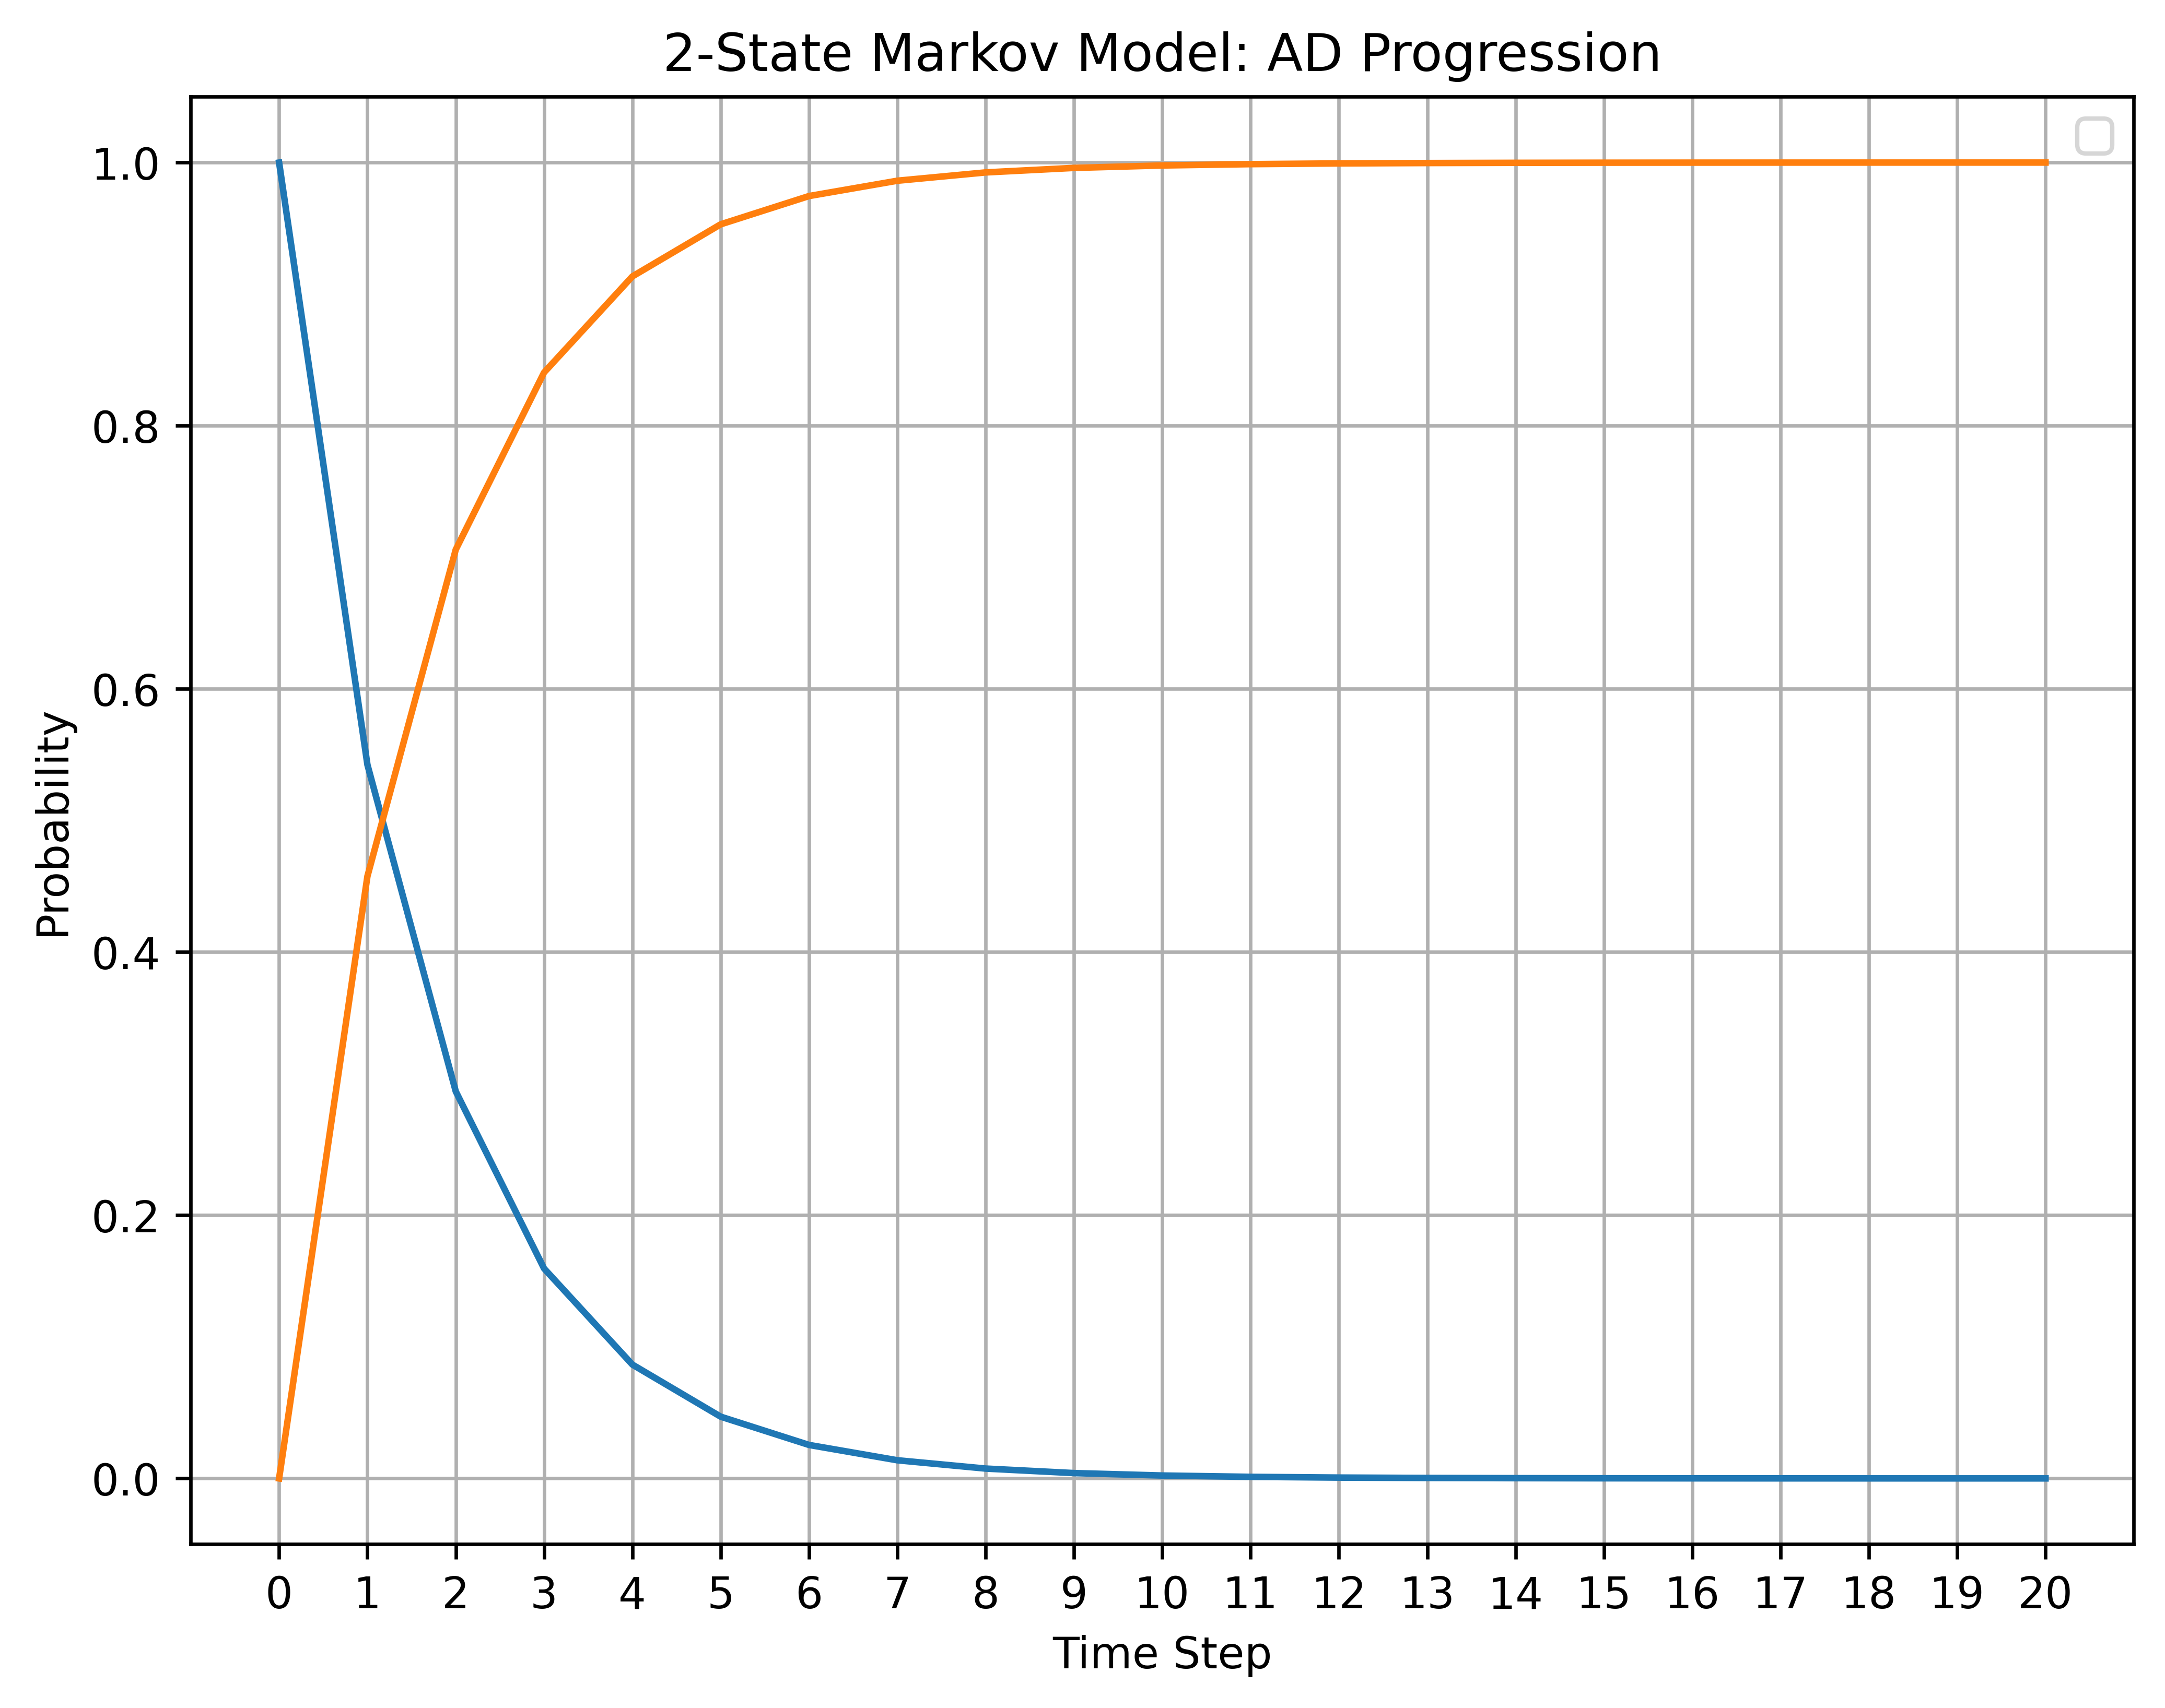

Transition matrix: 
 [[0.54234059 0.45765941]
 [0.         1.        ]]
Time       No AD        AD
Time 1: [0.56642294 0.43357706]
Time 2: [0.32083494 0.67916506]
Time 3: [0.18172827 0.81827173]
Time 4: [0.10293506 0.89706494]
Time 5: [0.05830478 0.94169522]
Time 6: [0.03302516 0.96697484]
Time 7: [0.01870621 0.98129379]
Time 8: [0.01059563 0.98940437]
Time 9: [0.00600161 0.99399839]
Time 10: [0.00339945 0.99660055]
Time 11: [0.00192552 0.99807448]
Time 12: [0.00109066 0.99890934]
Time 13: [6.17775674e-04 9.99382224e-01]
Time 14: [3.49922311e-04 9.99650078e-01]
Time 15: [1.98204023e-04 9.99801796e-01]
Time 16: [1.12267305e-04 9.99887733e-01]
Time 17: [6.35907764e-05 9.99936409e-01]
Time 18: [3.60192743e-05 9.99963981e-01]
Time 19: [2.04021431e-05 9.99979598e-01]
Time 20: [1.15562418e-05 9.99988444e-01]


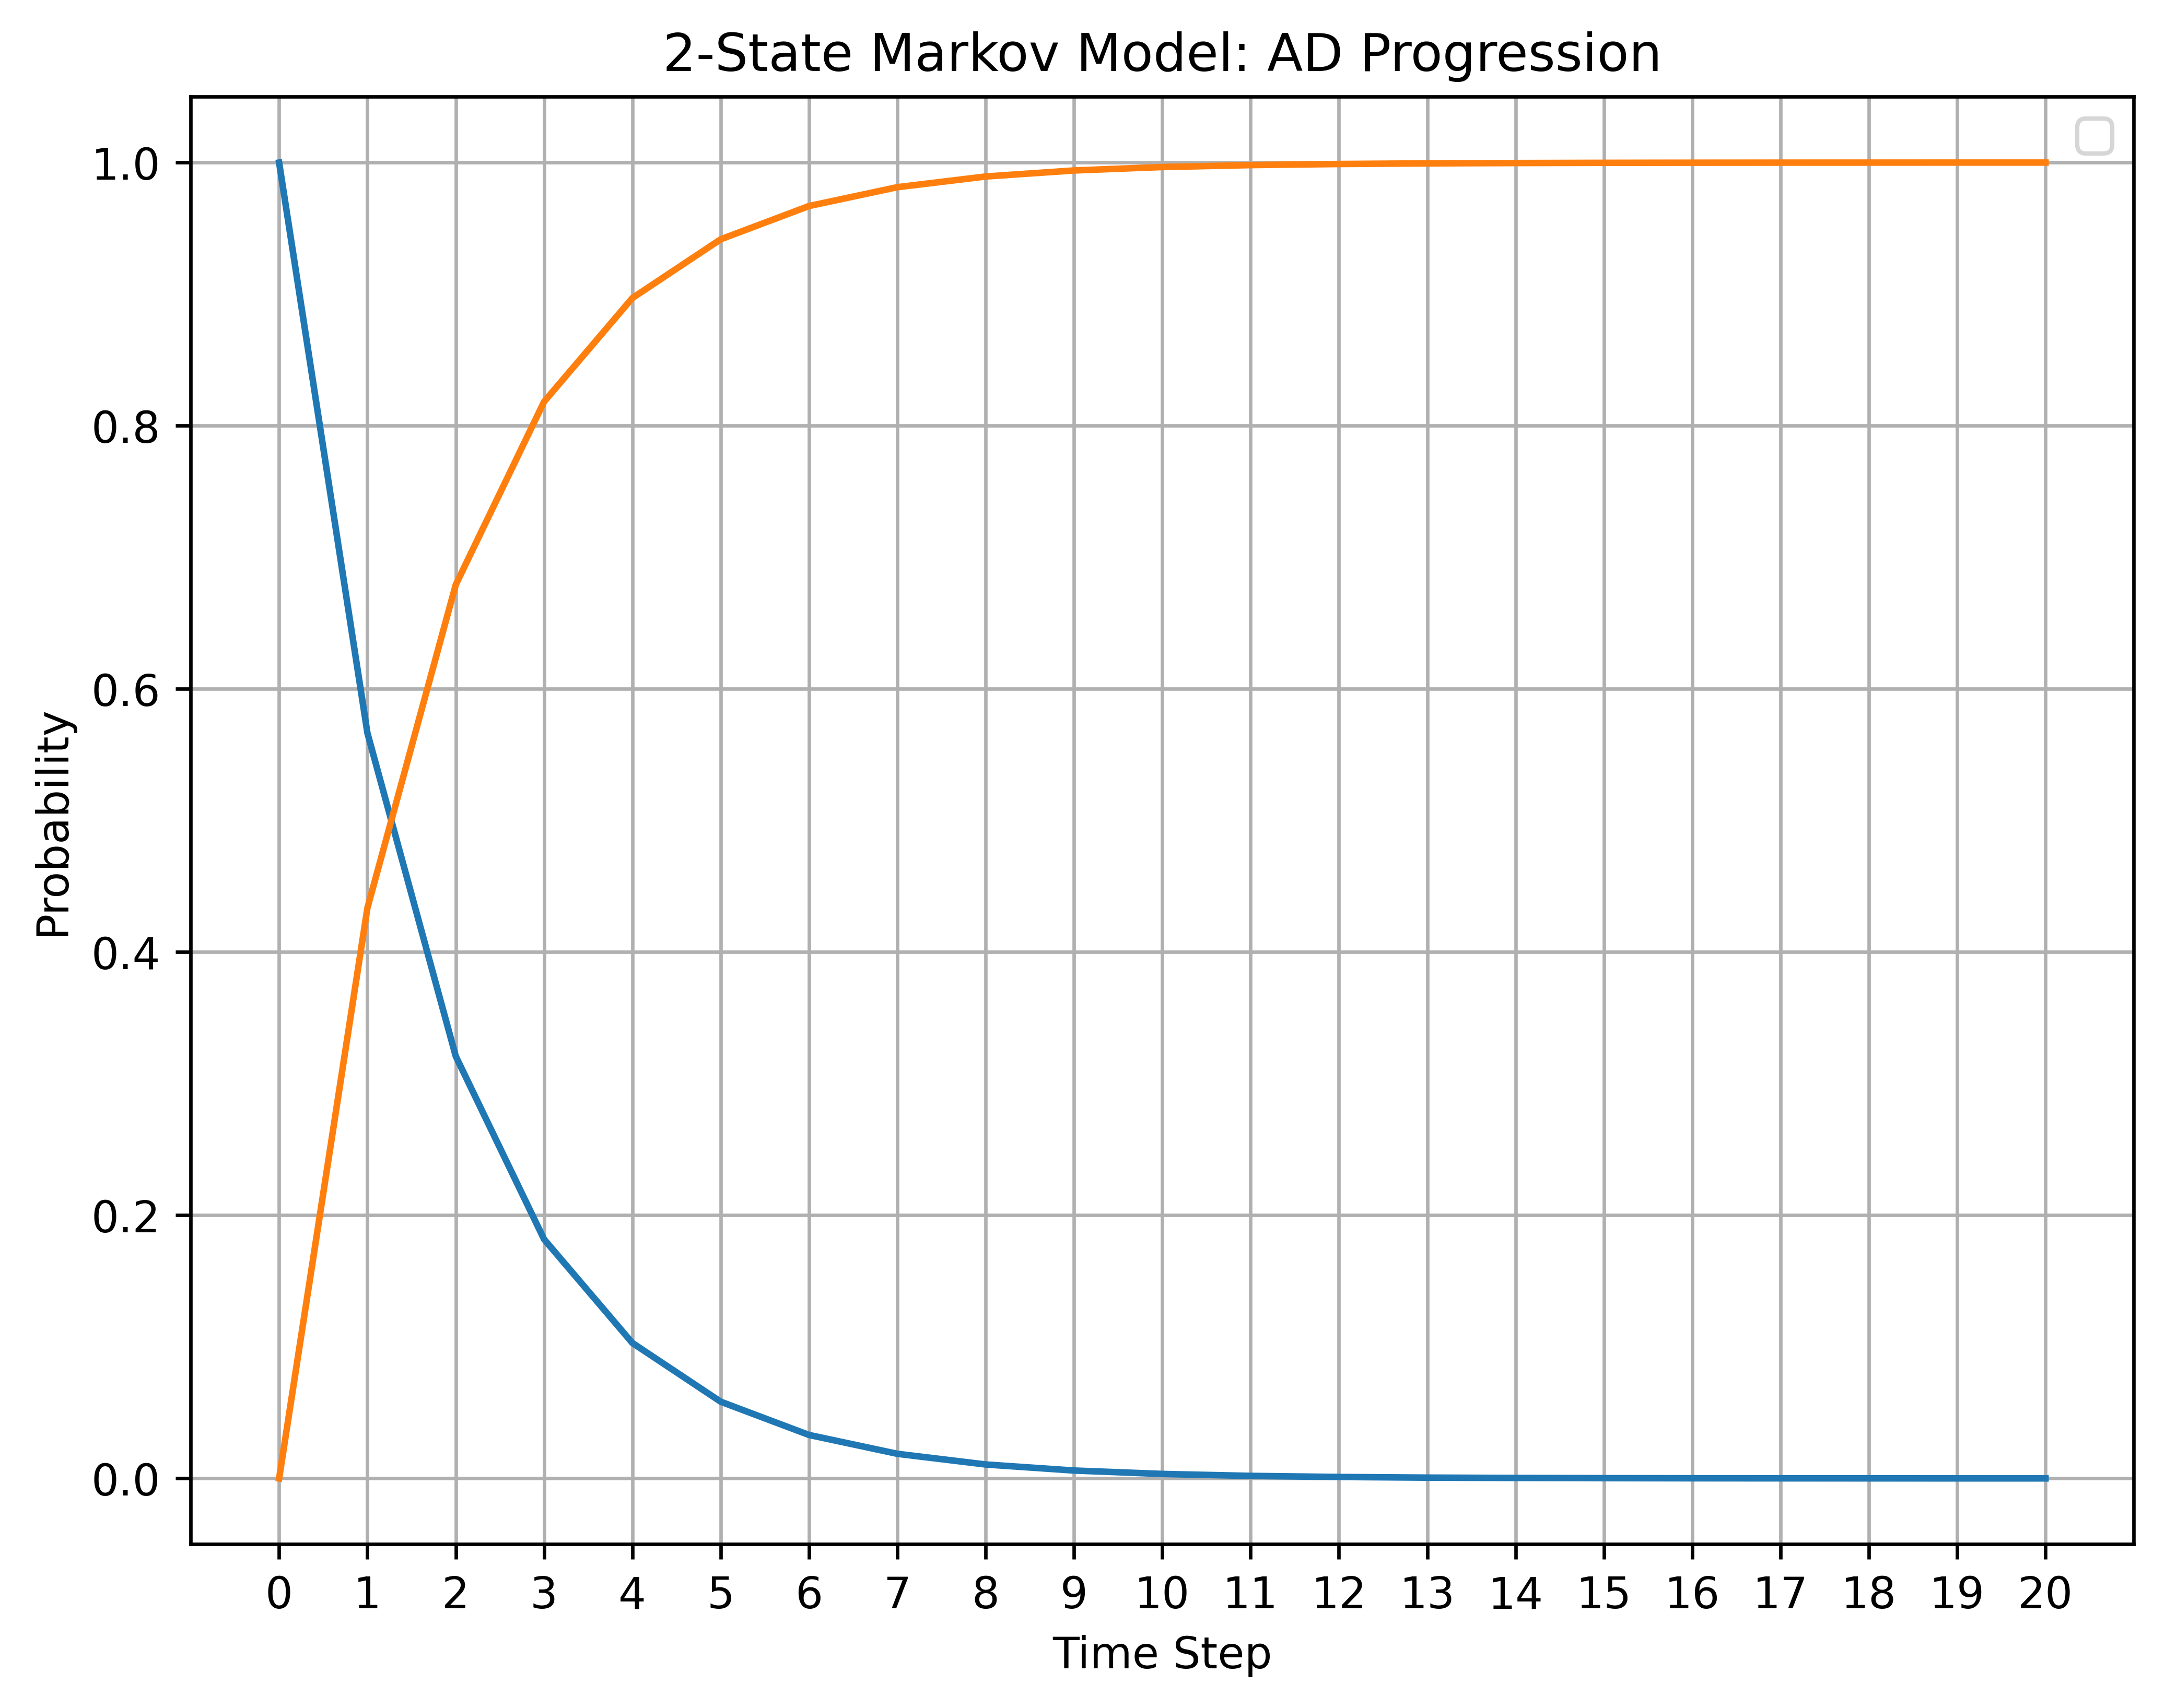

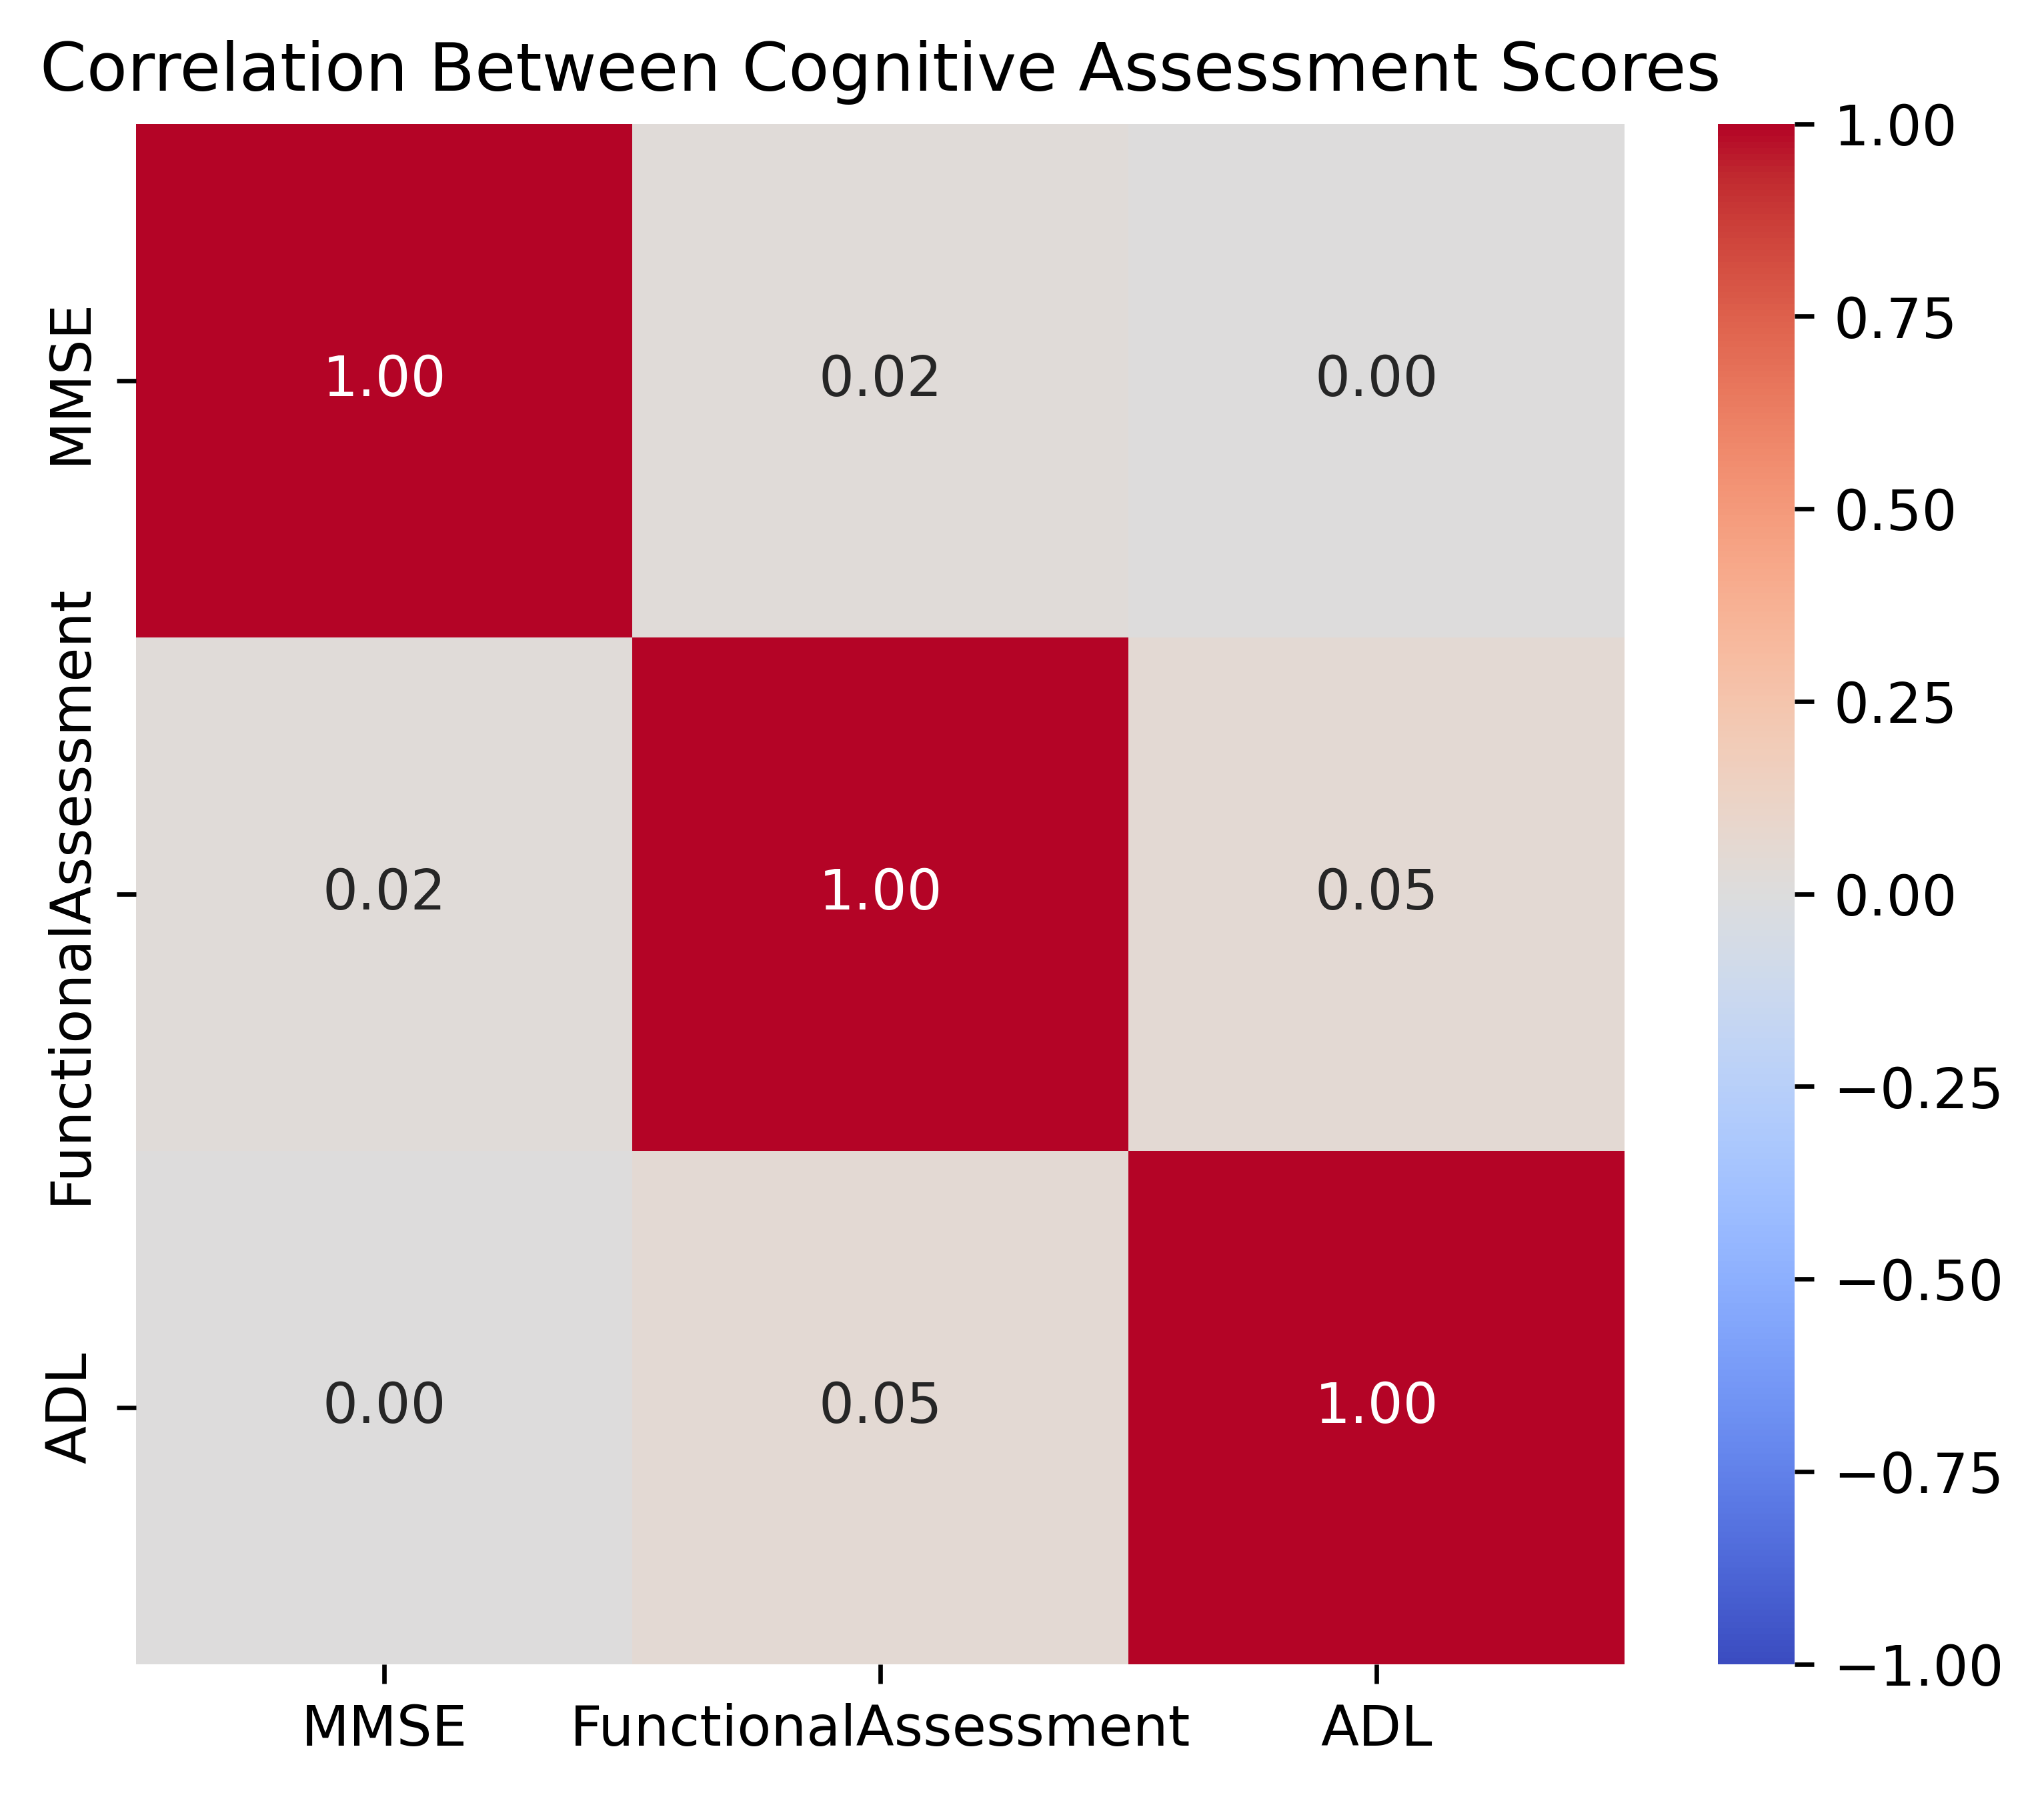

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


AD_data = pd.read_csv('AD_data.csv')

data = AD_data.drop(['PatientID', 'DoctorInCharge'], axis = 1)
data['Diagnosis'].value_counts()
data['MMSE_norm'] = 1 - (data['MMSE'] / data['MMSE'].max()) #MMSE_norm column contains normalised MMSE score values to calculate relative risk of AD progressions

p01 = data.loc[data['Diagnosis'] == 0 , 'MMSE_norm'].mean() #loc[Rows, Columns], p01 = probability of going from 0 to 1 
p00 = 1- p01 #prob of remaining in the no AD state
p10 = 0 #prob of transition from AD to no AD 
p11 = 1 #prob of remaining in the AD state

P = np.array([[p00, p01], [p10, p11]]) #transition matrix 
print(f'Transition matrix: \n {P}')

#2 state MC simulation with MMSE Scores only 
def markov_sim_2state(initial_state, P, steps):
    states = np.zeros((steps, 2)) #initalizing an array of 0s with two columns (AD, no AD)
    states[0, initial_state] = 1 #at time 0, assign 100% of the population to the initial state

    print('Time       No AD        AD')

    for t in range(1, steps):
        states[t] = states[t-1] @ P
        print(f'Time {t}: {states[t]}')

    return states

#markov_sim_2state(0, P, steps=21)

def run_sim_2state(initial_state, P, steps):
    state_prob = markov_sim_2state(0, P, steps = 21)
    state_prob_df = pd.DataFrame(
        state_prob,
        columns=['No_AD', 'AD']
    )

    
    plt.figure(figsize=(8, 6), dpi=600)
    plt.plot(state_prob_df)
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.title('2-State Markov Model: AD Progression')
    plt.xticks(range(0, 21))
    plt.grid()
    plt.show()

run_sim_2state(0, P, steps=21)

#2 state MC simulation with cognitive test scores
cognitive_tests = ['MMSE', 'FunctionalAssessment', 'ADL']
data['cognitive_risk'] = 0.0 #initialize cuulative cognitive risk

for test in cognitive_tests:
    values = data[test] #extract test values
    min_value = values.min() 
    max_value = values.max()
    range_value = max_value - min_value #calculating the range for min max scaling
    
    #0 - best performance 
    #1 - worst performance (the higher the worser)

    if range_value == 0:
        scaled = 0.0
    else: 
        scaled = (values - min_value)/range_value 

    data['cognitive_risk'] += 1 - scaled #converting performance to risk (the higher the worser) (inverting the scaled values)

data['cognitive_risk'] = data['cognitive_risk'] / len(cognitive_tests) #average risk 

p_01 = data.loc[data['Diagnosis'] == 0 , 'cognitive_risk'].mean()
p_00 = 1- p_01 #prob of remaining in the no AD state
p_10 = 0 #prob of transition from AD to no AD 
p_11 = 1 #prob of remaining in the AD state

P2 = np.array([[p_00, p_01], [p_10, p_11]]) #transition matrix 
print(f'Transition matrix: \n {P}')

#2 state MC simulation with cognitive scores 
#markov_sim(0, P2, steps=21)
run_sim_2state(0, P2, steps=21)

#correlation heatmap
corr_matrix = data[cognitive_tests].corr()

plt.figure(figsize=(6, 5), dpi = 600)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Correlation Between Cognitive Assessment Scores')
plt.show()





## 3-State Discrete Markov Chain


Time        NC        MCI        AD
Time 1: [0.89459123 0.10540877 0.        ]
Time 2: [0.80029347 0.16793825 0.03176828]
Time 3: [0.71593552 0.20168267 0.08238181]
Time 4: [0.64046963 0.21636507 0.1431653 ]
Time 5: [0.57295852 0.2186677  0.20837379]
Time 6: [0.51256366 0.21316009 0.27427625]
Time 7: [0.45853496 0.20294622 0.33851882]
Time 8: [0.41020135 0.19011554 0.39968312]
Time 9: [0.36696253 0.176057   0.45698048]
Time 10: [0.32828146 0.16167769 0.51004085]
Time 11: [0.29367771 0.14755473 0.55876756]
Time 12: [0.26272151 0.13404063 0.60323787]
Time 13: [0.23502836 0.12133637 0.64363527]
Time 14: [0.21025431 0.10954185 0.68020384]
Time 15: [0.18809166 0.09869058 0.71321776]
Time 16: [0.16826515 0.08877355 0.74296131]
Time 17: [0.15052852 0.07975544 0.76971604]
Time 18: [0.1346615  0.07158563 0.79375287]
Time 19: [0.120467   0.06420553 0.81532748]
Time 20: [0.10776872 0.05755343 0.83467785]


/var/folders/fl/8y0jm7_n4zbg3z6snpxmp3pw0000gn/T/ipykernel_4309/562542630.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


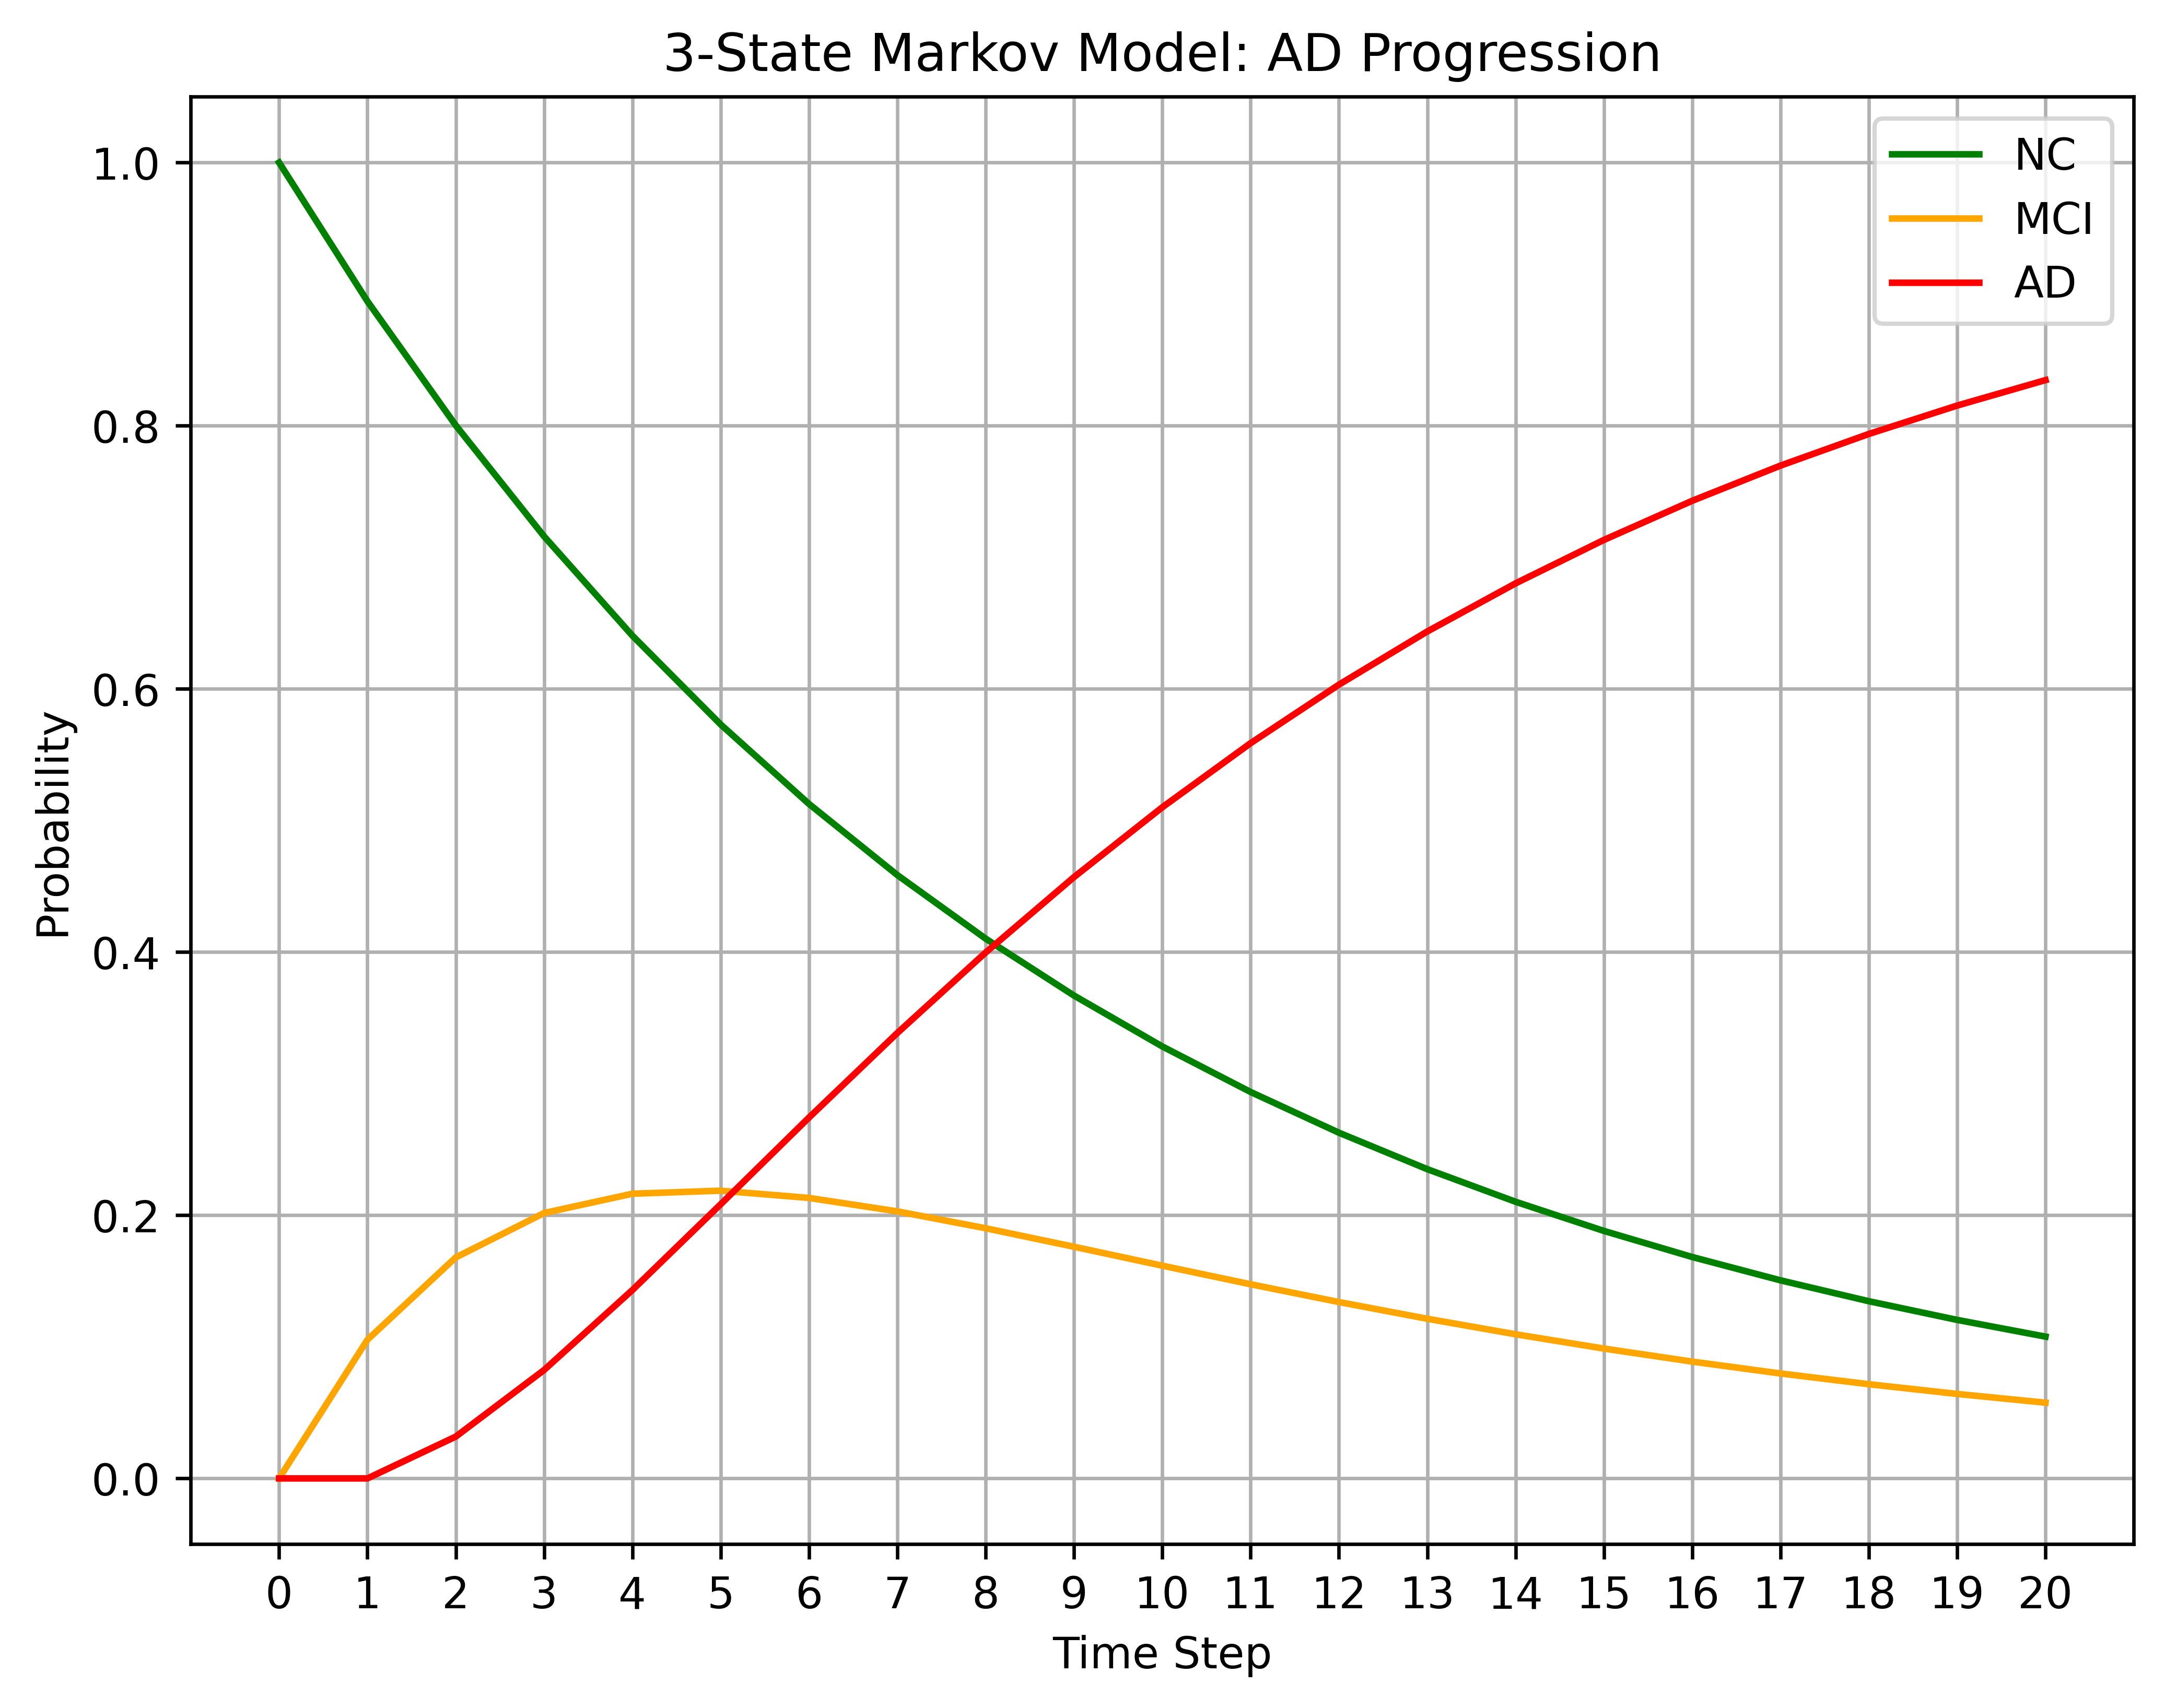

In [5]:
def define_states(MMSE_score):
    if MMSE_score >= 24:
        return 'NC' #Normal Control
    elif MMSE_score >= 18:
        return 'MCI' #Mild Cognitive Impairment
    else: 
        return 'AD' #Alzheimer's Disease
    
data['state'] = data['MMSE'].apply(define_states) #creating a new state column through the apply() function

#encode states 
state_map = {'NC': 0, 'MCI': 1, 'AD': 2}
data['state_id'] = data['state'].map(state_map) 

p3_01 = data.loc[data['state'] == 'NC' , 'MMSE_norm'].mean() #transition prob NC -> MCI
p3_00 = 1 - p3_01
p3_12 = data.loc[data["state"] == "MCI", "MMSE_norm"].mean() #transition prob MCI -> AD
p3_11 = 1 - p3_12
p3_22 = 1

P3 = np.array([[p3_00, p3_01, 0], [0, p3_11, p3_12], [0, 0, p3_22]]) #transition matrix of a 3 state model

#3 state MC simulation
def markov_sim_3state(initial_state, P, steps):
    states = np.zeros((steps, 3)) #initalizing an array of 0s with two columns (AD, no AD)
    states[0, initial_state] = 1 #at time 0, assign 100% of the population to the initial state

    print('Time        NC        MCI        AD')

    for t in range(1, steps):
        states[t] = states[t-1] @ P
        print(f'Time {t}: {states[t]}')

    return states
#markov_sim_3state(0, P3, steps = 21)

def run_sim_3state(initial_state, P, steps):
    state_prob = markov_sim_3state(0, P3, steps = 21)
    state_prob_df = pd.DataFrame(
        state_prob,
        columns=['NC', 'MCI', 'AD']
    )



    plt.figure(figsize=(8,6), dpi=600)
    plt.legend()
    plt.plot(state_prob_df['NC'], color='green', label='NC')
    plt.plot(state_prob_df['MCI'], color='orange', label='MCI')
    plt.plot(state_prob_df['AD'], color='red', label='AD')
    plt.legend()
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.title('3-State Markov Model: AD Progression')
    plt.xticks(range(0, 21))
    plt.grid()
    plt.show()

run_sim_3state(0, P3, steps=21)
